In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
"""Leaky integrate-and-fire neuron, with arbitrary input current and
optional white noise.

    tau_m du/dt = -(u - u_rest) + R I(t) + noise, reset u -> u_rest at u_th

    Consolidates lif_mod.py, lif_per.py, lif_perforce.py, and the three
integration loops in LIF_Model.ipynb and the two in Noisy_IF.ipynb, which
were all the same Euler scheme with different I(t).

From the LIF_Model notes: the model is an RC circuit. Charge leaks across
the membrane with time constant tau_m, injected current drives u upward,
and the spike itself is not modeled -- reaching u_th is declared a spike
and u is reset. Everything interesting is in what I(t) does and in when
the threshold is crossed.

Fixed from the originals: those initialized the spike list as the scalar 0,
which left a phantom spike at t = 0 and corrupted any rate or ISI estimate
built from it. Here spikes starts empty.

Regression check: with the defaults (constant I = 1.1, tau_m = 1, R = 1,
u_th = 1) the neuron fires periodically with ISI = tau_m*log(R*I/(R*I-u_th))
= 2.398 ms. If you get 0 spikes, R*I is below threshold.
"""

__all__ = ["lif_sim"]

def lif_sim(T=10.0, dt=1e-3, urest=0.0, uth=1.0, sigma=0, seed=None):
    """Integrate the LIF model by Euler-Maruyama.

    sigma : white noise amplitude; the increment is sqrt(2*dt)*sigma*randn.

    Returns t, u, spikes, rate (Hz, 0 if fewer than two spikes).
    """
    rng = np.random.default_rng(seed)
    nt = round(T / dt) + 1
    t = np.linspace(0.0, T, nt)
    u = np.zeros(nt)
    u[0] = urest
    spikes = []
    for j in range(nt - 1):
        du = dt + np.sqrt(2 * sigma**2 * dt) * rng.standard_normal()
        u[j + 1] = u[j] + du
        if u[j + 1] > uth:
            u[j + 1] = urest
            spikes.append(t[j + 1])

    # Skip first spike (on average) in order to get more stable solution
    kept_t = t[t > 1.0]
    kept_u = u[t > 1.0]
    spikes = np.array(spikes[1:])

    rate = 1000 * (len(spikes) - 1) / (spikes[-1] - spikes[0]) if len(spikes) >= 2 else 0.0 # Spikes per second

    return kept_t, kept_u, spikes, rate

def calculate_p(u, uth = 1.0, sigma = 0):
    if 0 <= u <= uth:
        return 1 - np.exp((u - 1) / (sigma**2))
    elif u < 0:
        return (1 - np.exp(-1/(sigma**2))) * np.exp(u/sigma**2)
    else:
        return 0

Spike Rate:  1020.268 Hz
Fraction of Time Below 0:  0.228


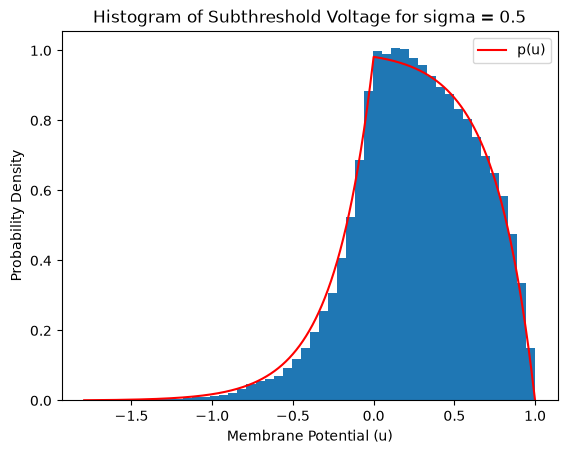

Spike Rate:  1008.97 Hz
Fraction of Time Below 0:  0.62


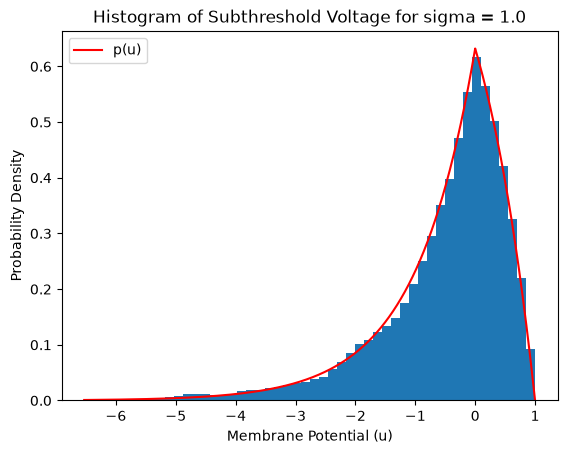

Spike Rate:  837.049 Hz
Fraction of Time Below 0:  0.892


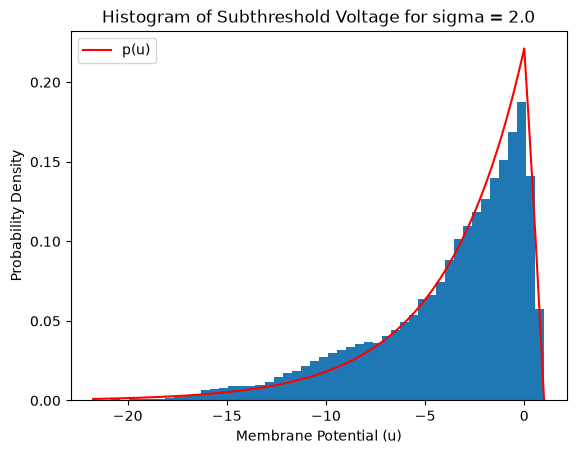

In [6]:
for sigma in [np.sqrt(0.25), np.sqrt(1), np.sqrt(4)]:
    t, u, spikes, rate = lif_sim(T = 1000.0, sigma = sigma)
    p_u = np.zeros(len(np.unique(u)))
    for i, voltage in enumerate(sorted(np.unique(u))):
        p_u[i] = calculate_p(voltage, uth = 1.0, sigma = sigma)

    print("Spike Rate: ", np.round(rate, 3), "Hz")
    print("Fraction of Time Below 0: ", np.round(np.sum(u < 0) / len(u), 3))

    plt.hist(u, bins=50, density=True);
    plt.plot(np.unique(u), p_u, color = 'r', label = 'p(u)');

    plt.xlabel("Membrane Potential (u)")
    plt.ylabel("Probability Density")
    plt.title(f"Histogram of Subthreshold Voltage for sigma = {sigma}")

    plt.legend()
    plt.show()

In [20]:
isi = np.diff(spikes)
s = np.std(isi, ddof = 1)
se = s/np.sqrt(len(isi))
se_rate = se / np.mean(isi) * 1000
print("Mean ISI: ", np.round(np.mean(isi), 3), "ms")
print("Standard Deviation: ", np.round(s, 3), "ms")
print("Standard Error: ", np.round(se, 3), "ms")
print("Standard Error of Rate: ", se_rate, "Hz")

print("Standard Errors From 1000 Spikes per Second:", (1000 - len(spikes))/ se_rate)

Mean ISI:  1.195 ms
Standard Deviation:  3.299 ms
Standard Error:  0.114 ms
Standard Error of Rate:  95.79971430775325 Hz
Standard Errors From 1000 Spikes per Second: 1.7536586743913019
